# Alternative visualization: periodicity of particles 1–6
This notebook reads the original saved BM4 run directly through `study_io.load_calculation`. It is an alternative to `visualizacion.ipynb` in the same study folder. **Run all cells to display the analysis; no calculation notebook, new trajectories or reference integrations are needed.** Diagnostic reductions (spectra and repetition defects) are computed in memory from the saved positions. Only optional figures are exported.

The original particle IDs and initial conditions are retained. The record contains 5,000 forcing cycles at 20 saved steps per cycle, in float64. The source has no independently audited trajectory reference; all interpretations below concern the saved numerical trajectories. Newton tolerances do not certify trajectory accuracy, and no exact physical periodicity is claimed.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import periodogram, find_peaks
from IPython.display import display, Markdown
from study_io import ROOT, load_calculation

# Saved source run and display/diagnostic choices; no integration is performed.
RUN_ID = 'aws_48p_5000c_20s_16proc_spot_20260920'
PARTICLE_IDS = np.arange(1, 7)
MAX_LAG = 1000
THRESHOLDS_OVER_L = [1e-4, 1e-3, 1e-2]
SAVE_FIGURES = True
RESULTS, source_meta, arrays, _, initial_table = load_calculation(RUN_ID)
idx = np.array([np.flatnonzero(arrays['particle_ids'] == p).item() for p in PARTICLE_IDS])
L = source_meta['field_provenance']['grid']['period']
T = source_meta['cycle_duration']; steps = source_meta['steps_per_cycle']
cycle_times = arrays['cycle_times']; times = arrays['times']
z = arrays['cycle_positions'][:, idx]
count = source_meta['particle_count']
xy = np.stack((arrays['states'][idx].T, arrays['states'][count+idx].T), axis=-1)
colors = arrays['colors_rgba'][idx]
initial = initial_table[initial_table['particle'].isin(PARTICLE_IDS)].copy()
assert z.shape == (5001, 6, 2) and np.isfinite(xy).all()
np.testing.assert_allclose(z, xy[::steps], rtol=0, atol=0)
np.testing.assert_allclose(np.diff(cycle_times), T)
FIG = ROOT / 'figuras' / RUN_ID / 'periodicity_first_six'
if SAVE_FIGURES: FIG.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'figure.dpi':110, 'font.size':10,
                     'axes.spines.top':False, 'axes.spines.right':False})
def finish(fig, name):
    if SAVE_FIGURES: fig.savefig(FIG / (name+'.png'), dpi=160, bbox_inches='tight')
    plt.show(); plt.close(fig)
print('Saved run:', RUN_ID)
print('Method:', source_meta['method'], '| step:', source_meta['step'], '| arithmetic:', source_meta['arithmetic'])
print('Cycle duration (s):', source_meta['time_scale_s'])
print('Length unit (m):', source_meta['length_scale_m'], '| normalized cell period:', L)
print('rho:', source_meta['rho'], '| field:', source_meta['field_provenance']['source_hdf5'])
display(initial)


Saved run: aws_48p_5000c_20s_16proc_spot_20260920
Method: BM4Implicit | step: 0.05 | arithmetic: float64
Cycle duration (s): 0.002613521842534343
Length unit (m): 0.00954929658551372 | normalized cell period: 18.84955592153019
rho: 0.3 | field: /home/juan/Proyectos/GC2D_intranet/data/potential/V1/PHI_2.h5


,cycle,time_normalized,time_s,particle,color,initial_radius_over_L,x_unwrapped,y_unwrapped,x_wrapped,y_wrapped,x_over_L,y_over_L,R_wrapped_m,Z_wrapped_m
0,0,0,0,1,#372466,0.000000,9.424778,9.424778,9.424778,9.424778,0.500000,0.5,0.090703,0.090352
1,0,0,0,2,#3c3286,0.010426,9.621295,9.424778,9.621295,9.424778,0.510426,0.5,0.092580,0.090352
2,0,0,0,3,#4040a2,0.020851,9.817811,9.424778,9.817811,9.424778,0.520851,0.5,0.094456,0.090352
3,0,0,0,4,#434eba,0.031277,10.014328,9.424778,10.014328,9.424778,0.531277,0.5,0.096333,0.090352
4,0,0,0,5,#455ed3,0.041702,10.210845,9.424778,10.210845,9.424778,0.541702,0.5,0.098210,0.090352
5,0,0,0,6,#466be3,0.052128,10.407361,9.424778,10.407361,9.424778,0.552128,0.5,0.100086,0.090352


## Repetition defects and spectra
For each lag q we evaluate RMS, 95th percentile and maximum of d(z(n+q),z(n))/L over **all** valid starting cycles. We also compare the first and second halves. A candidate chosen by smallest RMS is only a best approximate recurrence. The smallest q passing a maximum-distance threshold is reported separately.

The spectrum uses four smooth periodic observables: sin(2πx/L), cos(2πx/L), sin(2πy/L), cos(2πy/L). This avoids jumps at the cell boundary. Their demeaned Hann-window periodograms are summed, using 5,000 returns (excluding the initial point). Frequencies are in inverse forcing cycles, limited to [0,0.5] by sampling. The strongest peak can be a harmonic; 1/f is an oscillation timescale, not a certified return period. Split-window peaks are bin estimates without artificial zero-padding precision.

The integer-lag search covers 1–1,000 cycles, retaining at least five repetitions in the full record. All distances use the minimum image on the periodic spatial domain and are divided by L. For the best lag, repetition is also checked at every saved within-cycle phase. Thresholds measure geometric proximity, not numerical uncertainty.

In [2]:
def distance(a,b):
    delta = (a-b+L/2) % L - L/2
    return np.linalg.norm(delta, axis=-1)/L

def spectrum(points):
    angle = 2*np.pi*points/L
    obs = np.concatenate((np.sin(angle),np.cos(angle)),axis=-1)
    f,p = periodogram(obs,fs=1.0,window='hann',detrend='constant',axis=0,scaling='spectrum')
    return f,p.sum(axis=-1)

lags = np.arange(1, min(MAX_LAG,(len(z)-1)//5)+1)
metrics = np.empty((len(lags),6,5))
for i,q in enumerate(lags):
    d = distance(z[q:],z[:-q])
    half = (len(z)-1)//2
    first = distance(z[q:half+1],z[:half+1-q])
    second = distance(z[half+q:],z[half:-q])
    metrics[i] = np.stack([np.sqrt(np.mean(d*d,axis=0)),np.quantile(d,.95,axis=0),
                          d.max(axis=0),np.sqrt(np.mean(first*first,axis=0)),
                          np.sqrt(np.mean(second*second,axis=0))],axis=-1)
f,power = spectrum(z[1:])
fhalf,pfirst = spectrum(z[1:2501]); _,psecond = spectrum(z[2501:])
rows=[]; candidate_rows=[]; defects=[]
for j,pid in enumerate(PARTICLE_IDS):
    best = int(np.argmin(metrics[:,j,0])); q=int(lags[best])
    peak = 1+int(np.argmax(power[1:,j]))
    peak1=1+int(np.argmax(pfirst[1:,j])); peak2=1+int(np.argmax(psecond[1:,j]))
    full_defect = distance(xy[q*steps:,j],xy[:-q*steps,j])
    defects.append(distance(z[q:,j],z[:-q,j]))
    row = dict(particle=int(pid),best_q=q,rms_over_L=metrics[best,j,0],
        p95_over_L=metrics[best,j,1],max_over_L=metrics[best,j,2],
        first_half_rms=metrics[best,j,3],second_half_rms=metrics[best,j,4],
        all_phases_rms=float(np.sqrt(np.mean(full_defect**2))),all_phases_max=float(full_defect.max()),
        peak_frequency=f[peak],oscillation_cycles=1/f[peak],
        first_half_frequency=fhalf[peak1],second_half_frequency=fhalf[peak2],
        frequency_bin=1/5000,half_frequency_bin=1/2500,
        peak_three_bin_power_fraction=power[max(1,peak-1):peak+2,j].sum()/power[1:,j].sum())
    for eps in THRESHOLDS_OVER_L:
        passing=lags[metrics[:,j,2] <= eps]
        row[f'smallest_q_max_below_{eps:g}']=int(passing[0]) if len(passing) else None
    rows.append(row)
    minima=find_peaks(-metrics[:,j,0])[0]
    candidates=sorted(set([best,0,len(lags)-1,*minima]),key=lambda i:metrics[i,j,0])[:10]
    for i in candidates:
        candidate_rows.append(dict(particle=int(pid),q=int(lags[i]),rms_over_L=metrics[i,j,0],max_over_L=metrics[i,j,2]))
summary=pd.DataFrame(rows)
candidates = pd.DataFrame(candidate_rows)
data = dict(lags=lags, metrics=metrics, frequency=f, power=power,
    half_frequency=fhalf, first_power=pfirst, second_power=psecond,
    cycle_times=cycle_times, cycle_xy=z, colors=colors,
    **{f'defect_{j+1}':d for j,d in enumerate(defects)})
meta = {'thresholds_over_L': THRESHOLDS_OVER_L}
# Plot coordinates below are fractions of the cell period; raw arrays remain unchanged.
z = data['cycle_xy'] / L
print('Spectral bin widths: full record 1/5000; half record 1/2500 cycles^-1.')
display(summary[['particle','best_q','rms_over_L','max_over_L','all_phases_max',
    'peak_frequency','oscillation_cycles','first_half_frequency','second_half_frequency']])


Spectral bin widths: full record 1/5000; half record 1/2500 cycles^-1.


,particle,best_q,rms_over_L,max_over_L,all_phases_max,peak_frequency,oscillation_cycles,first_half_frequency,second_half_frequency
0,1,149,0.000087,0.000178,0.000201,0.1276,7.836991,0.1276,0.1276
1,2,88,0.000011,0.000015,0.000017,0.1478,6.765900,0.1476,0.1476
2,3,835,0.000031,0.000053,0.000060,0.1450,6.896552,0.1448,0.1448
3,4,975,0.000084,0.000494,0.000542,0.1282,7.800312,0.1284,0.1284
4,5,712,0.000032,0.000061,0.000073,0.1250,8.000000,0.1248,0.1248
5,6,17,0.010743,0.048923,0.053824,0.1176,8.503401,0.1176,0.1176


## Individual Poincaré sections
Colour indicates cycle number, revealing slow evolution. The cross marks the initial point. A finite set of repeating points is consistent with periodicity; a smooth closed curve is consistent with quasiperiodic motion. Neither visual impression alone proves the dynamical classification.

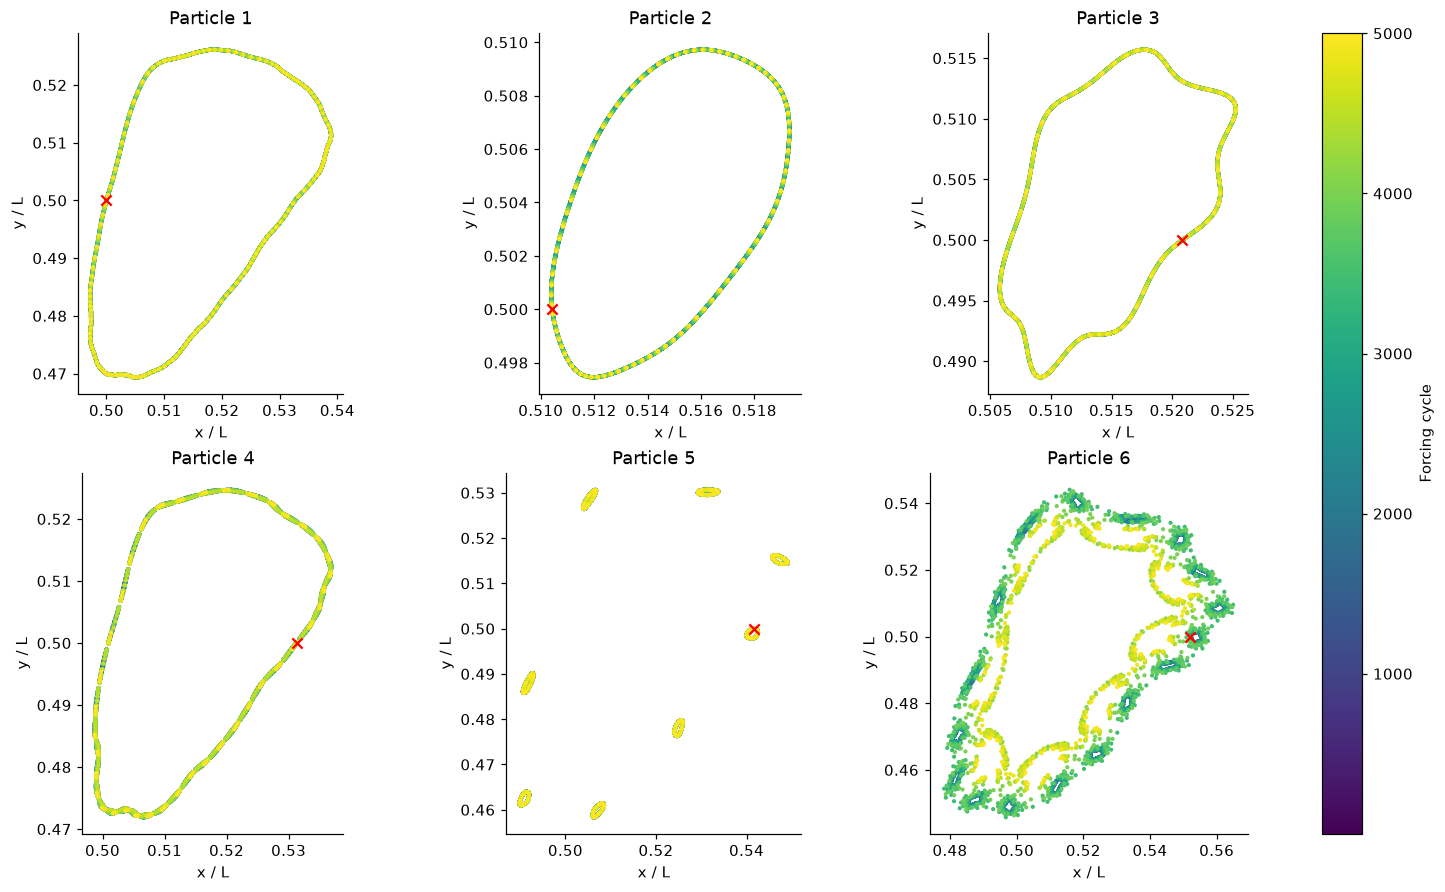

In [3]:
fig,axes=plt.subplots(2,3,figsize=(14,8),layout='constrained')
for j,ax in enumerate(axes.flat):
    wrapped=z[:,j]%1
    sc=ax.scatter(*wrapped[1:].T,c=np.arange(1,len(z)),s=3,cmap='viridis',rasterized=True)
    ax.scatter(*wrapped[0],marker='x',c='red',s=45)
    ax.set(title=f'Particle {j+1}',xlabel='x / L',ylabel='y / L',aspect='equal')
fig.colorbar(sc,ax=axes.ravel().tolist(),label='Forcing cycle')
finish(fig,'poincare_sections')


## Particle 5: the eight-cycle structure
The saved section shows eight small loops. To inspect this structure, colour each return by its cycle index modulo eight and zoom into one subsequence. If eight cycles were an exact orbit period, each subsequence would collapse to a single point within numerical uncertainty. A resolved loop instead indicates motion around a candidate resonance island; its existence does not prove that this initial condition lies on an exact period-eight orbit. The q=8 repetition defect below is taken from the lag scan above. The best long recurrence (q=712) is a different diagnostic.

Particles 1–4 trace near-closed curves, visually consistent with quasiperiodicity. Particle 6 spreads through a wider, evolving region; these data alone cannot distinguish physical irregularity from accumulated numerical error.

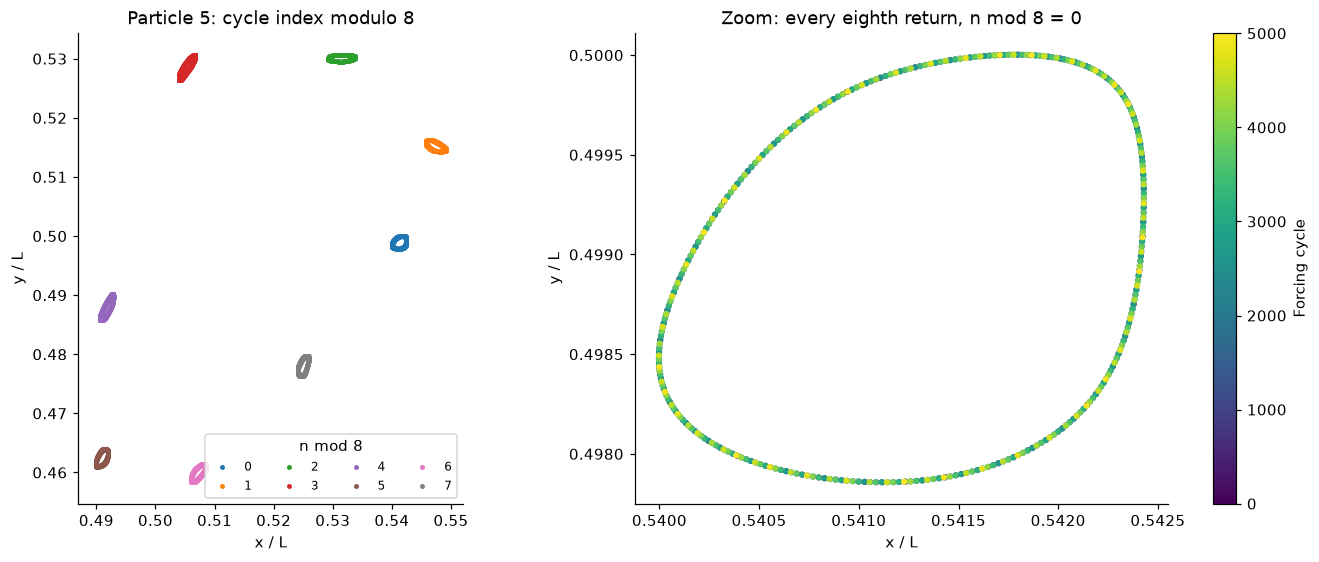

Particle 5, q=8: RMS=0.00193088 L; maximum=0.00360439 L


In [4]:
j=4; island_period=8
cycles=np.arange(len(z)); points=z[:,j]%1
fig,axes=plt.subplots(1,2,figsize=(12,5),layout='constrained')
for residue in range(island_period):
    select=cycles%island_period==residue
    axes[0].scatter(*points[select].T,s=5,label=str(residue))
select=cycles%island_period==0
sc=axes[1].scatter(*points[select].T,c=cycles[select],s=9,cmap='viridis')
axes[0].set(title='Particle 5: cycle index modulo 8',xlabel='x / L',ylabel='y / L',aspect='equal')
axes[0].legend(title='n mod 8',ncol=4,fontsize=8)
axes[1].set(title='Zoom: every eighth return, n mod 8 = 0',xlabel='x / L',ylabel='y / L',aspect='equal')
axes[1].ticklabel_format(useOffset=False)
fig.colorbar(sc,ax=axes[1],label='Forcing cycle')
finish(fig,'particle_5_eight_islands')
k=int(np.flatnonzero(data['lags']==island_period)[0])
print(f"Particle 5, q=8: RMS={data['metrics'][k,j,0]:.6g} L; maximum={data['metrics'][k,j,2]:.6g} L")


## Does the entire sequence repeat after q cycles?
The best q minimizes RMS within the searched range. Maximum defects must also be small. The dashed horizontal lines are exploratory geometric thresholds, not integration error estimates. A small isolated return to the initial state would be weaker evidence than this test over every starting phase.

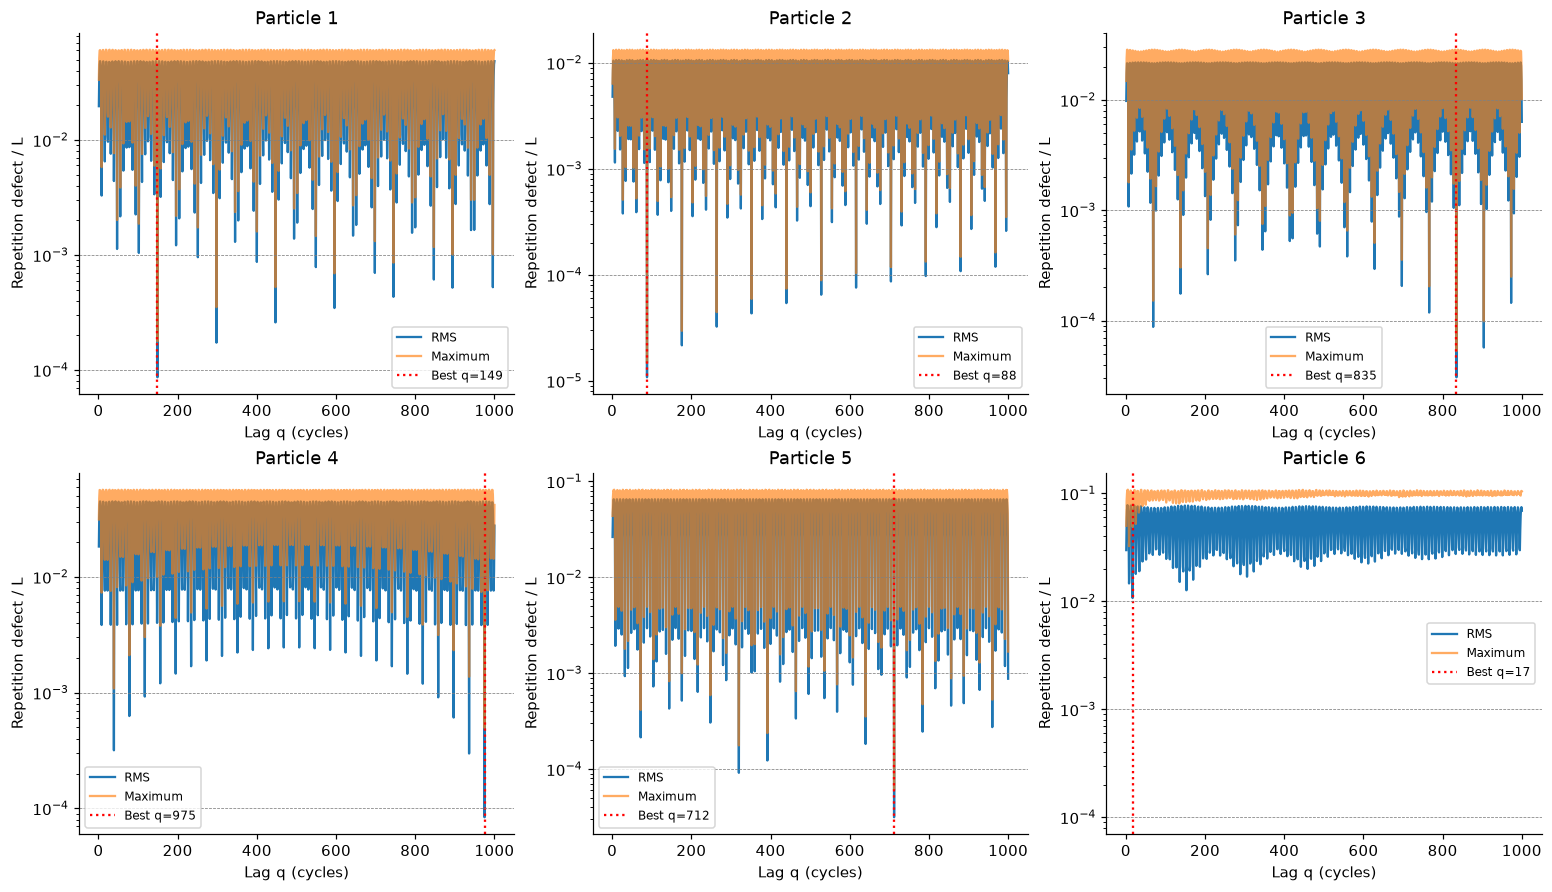

,particle,q,rms_over_L,max_over_L
0,1,149,0.000087,0.000178
1,1,298,0.000173,0.000352
2,1,447,0.000259,0.000526
3,1,596,0.000346,0.000693
4,1,745,0.000433,0.000858
5,1,894,0.000520,0.001015
6,1,996,0.000525,0.001019
7,1,847,0.000612,0.001172
8,1,698,0.000699,0.001319
9,1,549,0.000785,0.001461


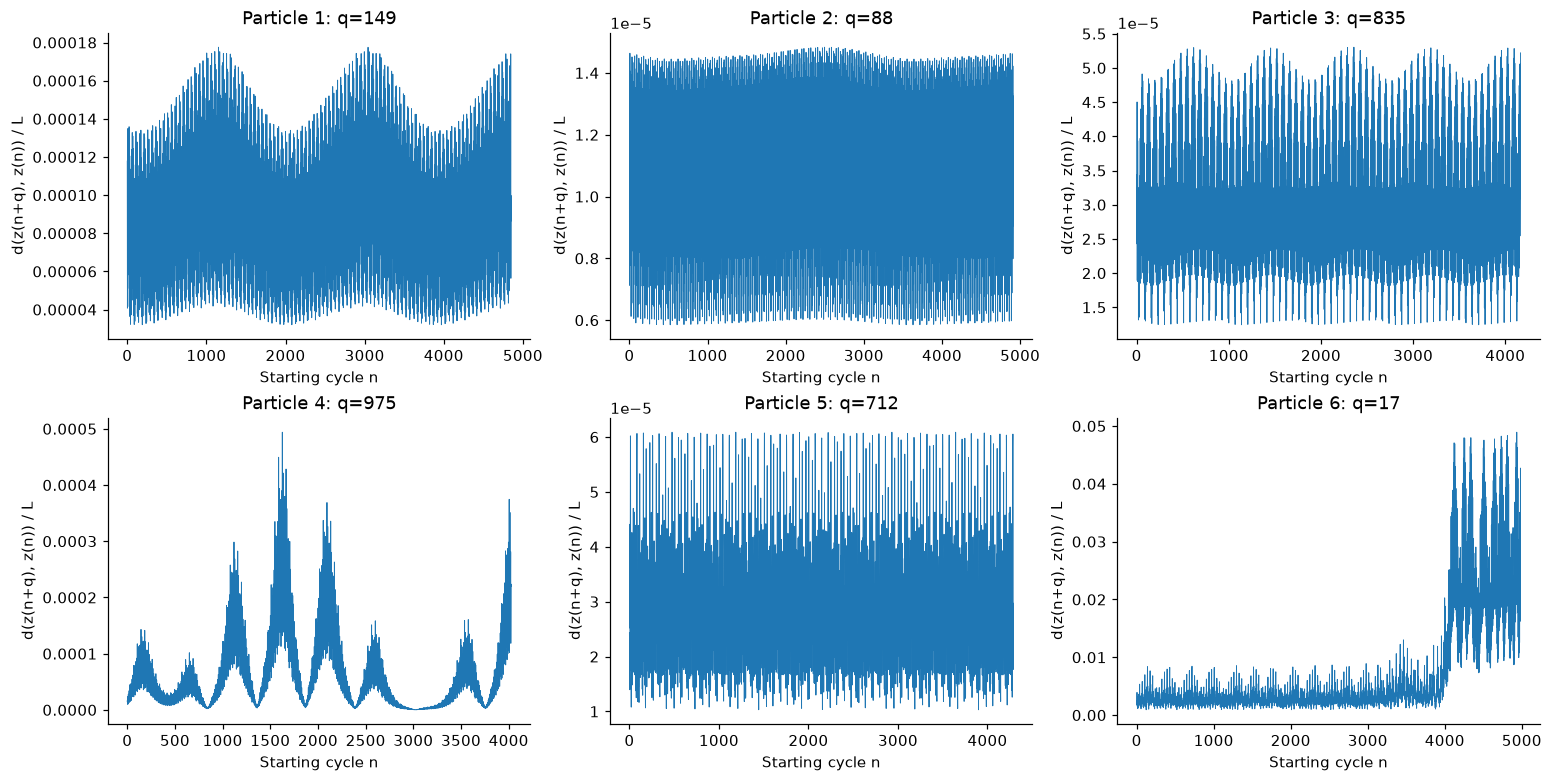

In [5]:
fig,axes=plt.subplots(2,3,figsize=(14,8),layout='constrained')
for j,ax in enumerate(axes.flat):
    ax.semilogy(data['lags'],data['metrics'][:,j,0],label='RMS')
    ax.semilogy(data['lags'],data['metrics'][:,j,2],alpha=.65,label='Maximum')
    q=int(summary.iloc[j].best_q); ax.axvline(q,color='red',ls=':',label=f'Best q={q}')
    for eps in meta['thresholds_over_L']: ax.axhline(eps,color='gray',ls='--',lw=.5)
    ax.set(title=f'Particle {j+1}',xlabel='Lag q (cycles)',ylabel='Repetition defect / L')
    ax.legend(fontsize=8)
finish(fig,'lag_scan')
display(candidates)
fig,axes=plt.subplots(2,3,figsize=(14,7),layout='constrained')
for j,ax in enumerate(axes.flat):
    d=data[f'defect_{j+1}']; ax.plot(np.arange(len(d)),d,lw=.6)
    ax.set(title=f'Particle {j+1}: q={int(summary.iloc[j].best_q)}',
           xlabel='Starting cycle n',ylabel='d(z(n+q), z(n)) / L')
finish(fig,'best_lag_history')


## Oscillation frequencies and their stability
Spectra of smooth torus observables avoid artificial boundary jumps. Full-record frequency-bin spacing is 0.0002 cycles⁻¹; half-record spacing is 0.0004 cycles⁻¹. Matching dominant bins is evidence of a stable oscillation, not a proof of a rational frequency or a periodic orbit. A dominant harmonic can change between windows. Frequencies above the stroboscopic Nyquist limit are not resolved.

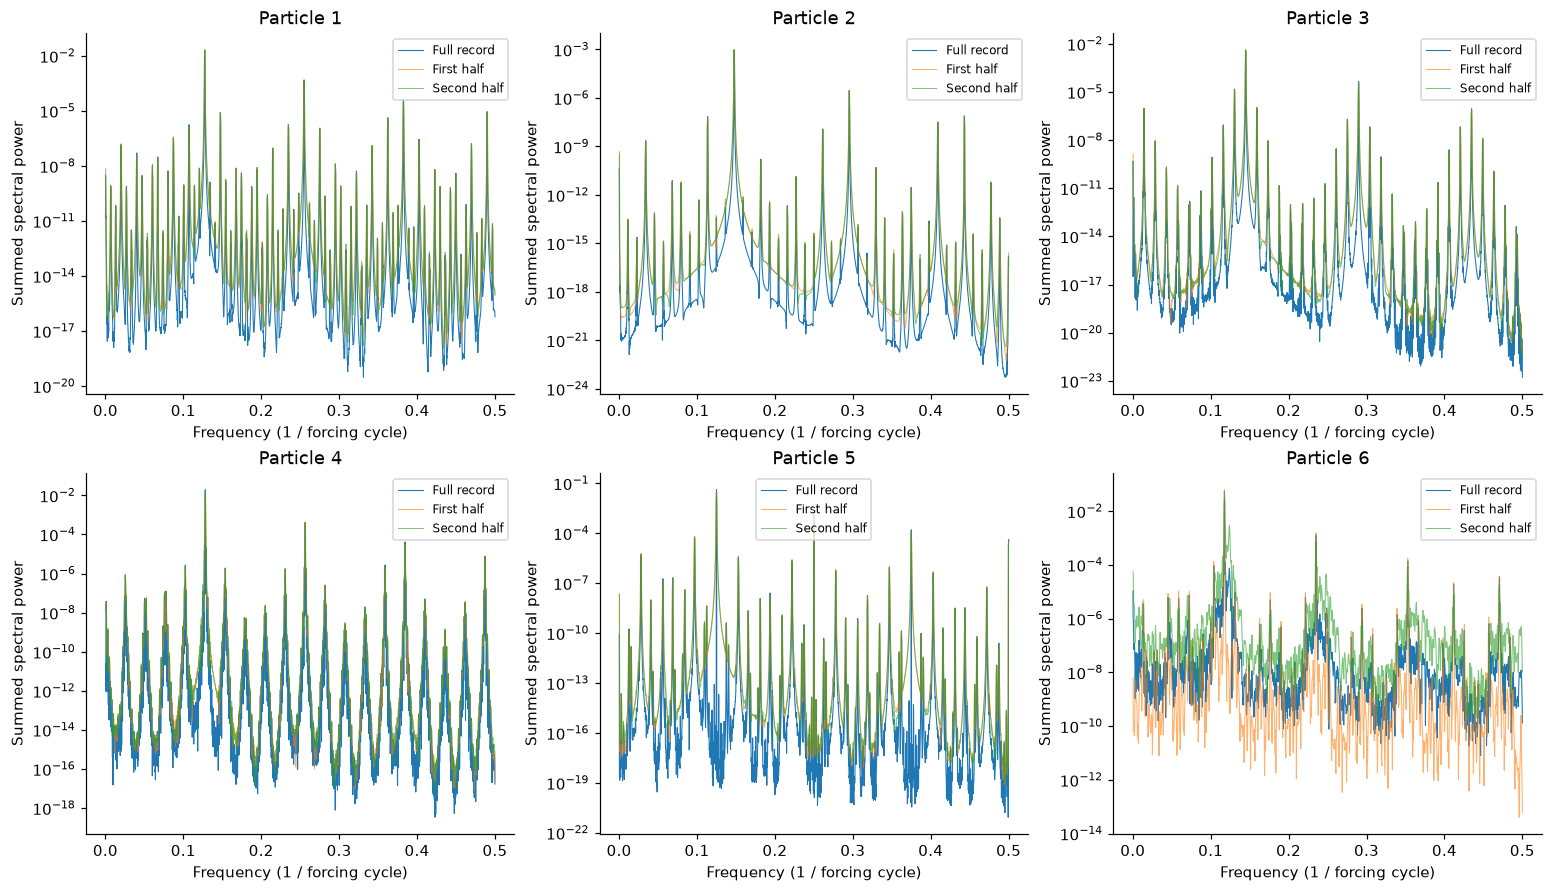

In [6]:
fig,axes=plt.subplots(2,3,figsize=(14,8),layout='constrained')
for j,ax in enumerate(axes.flat):
    for f,p,label,alpha in [(data['frequency'],data['power'],'Full record',1),
        (data['half_frequency'],data['first_power'],'First half',.6),
        (data['half_frequency'],data['second_power'],'Second half',.6)]:
        ax.semilogy(f[1:],np.maximum(p[1:,j],1e-30),lw=.7,label=label,alpha=alpha)
    ax.set(title=f'Particle {j+1}',xlabel='Frequency (1 / forcing cycle)',ylabel='Summed spectral power')
    ax.legend(fontsize=8)
finish(fig,'spectra')


## Data-driven interpretation
The statements below describe approximate repetition at explicit spatial thresholds. Exact periodicity cannot be established from finite, inexact data. Failure of this test does not prove chaos or exclude a period outside the searched range. Stable spectral peaks together with a persistent nonzero closure defect can be consistent with quasiperiodicity, but this study does not compute Lyapunov exponents or prove invariant tori.

In [7]:
lines=[]
for _,r in summary.iterrows():
    accepted=[]
    for eps in meta['thresholds_over_L']:
        q=r[f'smallest_q_max_below_{eps:g}']
        if pd.notna(q): accepted.append(f'q={int(q)} at {eps:g} L')
    verdict='; '.join(accepted) if accepted else 'No tested lag passes any selected maximum-distance threshold.'
    lines.append(f"- **Particle {int(r.particle)}:** best approximate lag **{int(r.best_q)} cycles**, "
        f"RMS {r.rms_over_L:.3g} L, maximum {r.max_over_L:.3g} L; "
        f"dominant oscillation timescale {r.oscillation_cycles:.5g} cycles. {verdict}")
text='\n'.join(lines)+'\n\nThese are diagnostics of the saved BM4 trajectories; exact physical periodicity is not certified.'
display(Markdown(text))
# The interpretation is displayed inline; no diagnostic result files are required.


- **Particle 1:** best approximate lag **149 cycles**, RMS 8.65e-05 L, maximum 0.000178 L; dominant oscillation timescale 7.837 cycles. q=149 at 0.001 L; q=8 at 0.01 L
- **Particle 2:** best approximate lag **88 cycles**, RMS 1.08e-05 L, maximum 1.48e-05 L; dominant oscillation timescale 6.7659 cycles. q=88 at 0.0001 L; q=27 at 0.001 L; q=1 at 0.01 L
- **Particle 3:** best approximate lag **835 cycles**, RMS 3.07e-05 L, maximum 5.3e-05 L; dominant oscillation timescale 6.8966 cycles. q=835 at 0.0001 L; q=69 at 0.001 L; q=7 at 0.01 L
- **Particle 4:** best approximate lag **975 cycles**, RMS 8.38e-05 L, maximum 0.000494 L; dominant oscillation timescale 7.8003 cycles. q=975 at 0.001 L; q=8 at 0.01 L
- **Particle 5:** best approximate lag **712 cycles**, RMS 3.15e-05 L, maximum 6.09e-05 L; dominant oscillation timescale 8 cycles. q=712 at 0.0001 L; q=72 at 0.001 L; q=8 at 0.01 L
- **Particle 6:** best approximate lag **17 cycles**, RMS 0.0107 L, maximum 0.0489 L; dominant oscillation timescale 8.5034 cycles. No tested lag passes any selected maximum-distance threshold.

These are diagnostics of the saved BM4 trajectories; exact physical periodicity is not certified.